<a href="https://colab.research.google.com/github/anuragN2107/Netflix-Movie-Recommendation-SVD/blob/main/Capstone_Project(Netflix).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Movie Recommendation System** Using SVD

**Project Name**- Capstone Project (Netflix)

**Problem Statement:**
 Customer Behaviour and it’s prediction lies at the core of every Business Model. From Stock Exchange, e-Commerce and Automobile to even Presidential Elections, predictions serve a great purpose. Most of these predictions are based on the data available about a person’s activity either online or in-person.

Recommendation Engines are the much needed manifestations of the desired Predictability of User Activity. Recommendation Engines move one step further and not only give information but put forth strategies to further increase users interaction with the platform.

In today’s world OTT platform and Streaming Services have taken up a big chunk in the Retail and Entertainment industry. Organizations like Netflix, Amazon etc. analyse User Activity Pattern’s and suggest products that better suit the user needs and choices.

For the purpose of this Project we will be creating one such Recommendation Engine from the ground-up, where every single user, based on there area of interest and ratings, would be recommended a list of movies that are best suited for them.

#Installing important libraries

In [2]:
# Supress Warnings
import warnings
warnings.filterwarnings("ignore")
# numpy & pandas
import numpy as np
import pandas as pd
import math
#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install scikit-surprise

In [5]:
# Downgrade numpy for surprise compatibility
!pip uninstall numpy -y
!pip install numpy==1.26.4 # Installing a compatible 1.x version for Python 3.12

# import libraries for model building
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy

Data Loading

In [6]:
# Reading dataset file
data = pd.read_csv('/content/drive/MyDrive/Netflix Datasets/combined_data_1.txt',header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])
data

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [7]:
data.dtypes #datatypes

,0
Cust_Id,object
Rating,float64


In [8]:
data.shape #shape

(24058263, 2)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_Id  object 
 1   Rating   float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


In [10]:
#get the customer count with NaN values
movie_count = data.isnull().sum()
movie_count

,0
Cust_Id,0
Rating,4499


In [11]:
# Determine the number of unique customers present in the dataset
customer_count=data['Cust_Id'].nunique()
customer_count

475257

In [12]:
#count without NaN values
customer_count = data['Cust_Id'].nunique()-movie_count
customer_count

,0
Cust_Id,475257
Rating,470758


In [13]:
# To determine the overall number of ratings recorded in the dataset
rating_count = data['Cust_Id'].count()-movie_count
rating_count

,0
Cust_Id,24058263
Rating,24053764


In [14]:
# To calculate the number of users for each star rating (1 to 5)
stars = data.groupby('Rating')['Rating'].agg(['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


<Figure size 1200x800 with 0 Axes>

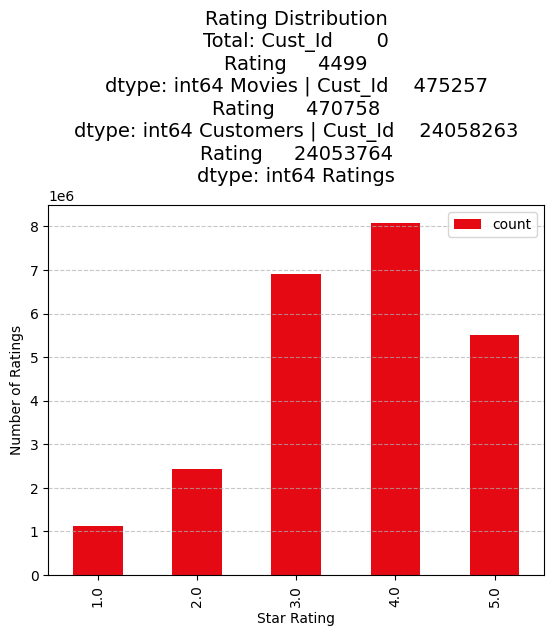

In [15]:
# To plot the distribution of the ratings in as a bar plot
plt.figure(figsize=(12, 8))
stars.plot(
    kind='bar',
    color = ['#E50914', '#1f77b4', '#E50914', '#1f77b4', '#E50914']
)

plt.title(
    f'Rating Distribution\nTotal: {movie_count} Movies | {customer_count} Customers | {rating_count} Ratings',
    fontsize=14
)
plt.xlabel('Star Rating')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [16]:
#Add another column that will have movie id
#first of all we will be calculating how many null values we are having in the ratings column
df_nan = pd.DataFrame(pd.isnull(data.Rating))
df_nan

,Rating
0,True
1,False
2,False
3,False
4,False
...,...
24058258,False
24058259,False
24058260,False
24058261,False


In [17]:
df_nan=df_nan[df_nan['Rating']==True]
df_nan

,Rating
0,True
548,True
694,True
2707,True
2850,True
...,...
24046714,True
24047329,True
24056849,True
24057564,True


In [18]:
df_nan.shape

(4499, 1)

In [19]:
df_nan.head()

,Rating
0,True
548,True
694,True
2707,True
2850,True


In [20]:
df_nan.tail()

,Rating
24046714,True
24047329,True
24056849,True
24057564,True
24057834,True


In [21]:
# Reset the index and add it as a column in the dataframe
df_nan=df_nan.reset_index()

In [22]:
# Create a NumPy array of movie IDs from the ratings dataset (optimized)

movie_np = []
movie_id = 1

for i, j in zip(df_nan['index'][1:], df_nan['index'][:-1]):
    movie_np.append(np.full(i - j - 1, movie_id))
    movie_id += 1

movie_np = np.concatenate(movie_np)

# Print outputs for verification
print("Movie ID array created successfully!")
print("Total number of movie IDs:", len(movie_np))
print("First 10 movie IDs:", movie_np[:10])
print("Last 10 movie IDs:", movie_np[-10:])


Movie ID array created successfully!
Total number of movie IDs: 24053336
First 10 movie IDs: [1 1 1 1 1 1 1 1 1 1]
Last 10 movie IDs: [4498 4498 4498 4498 4498 4498 4498 4498 4498 4498]


In [23]:
last_record = np.full((1,len(data) - df_nan.iloc[-1, 0] - 1),movie_id)
movie_np = np.append(movie_np, last_record)

print(f'Movie numpy: {movie_np}')
print(f'Length: {len(movie_np)}')


Movie numpy: [   1    1    1 ... 4499 4499 4499]
Length: 24053764


In [24]:
# Append the generated Movie_Id array to the dataset after removing NaN rating rows
data = data[pd.notnull(data['Rating'])]

# Assign movie IDs and ensure correct data types
data['Movie_Id'] = movie_np.astype(int)
data['Cust_Id'] = data['Cust_Id'].astype(int)

print("Updated dataset preview:")
data.head()


Updated dataset preview:


,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


#**Data Preprocessing**
### Filtering Data: Removing Infrequent Users and Movies

To improve the quality and efficiency of the recommendation system, we will filter out users who have rated very few movies and movies that have received very few ratings. This step helps in reducing sparsity and focusing on more significant rating patterns.

We will remove:
- Users who have rated less than 10 movies.
- Movies that have been rated less than 10 times.

In [25]:
# Count ratings per movie
f = ['count', 'mean']

df_movie_summary = data.groupby('Movie_Id')['Rating'].agg(f)
df_movie_summary.index = df_movie_summary.index.map(int)
movie_benchmark = round(df_movie_summary['count'].quantile(0.7),0)
drop_movie_list = df_movie_summary[df_movie_summary['count'] < movie_benchmark].index

print(f"Movie threshold: {movie_benchmark}")

# Count ratings per user
df_cust_summary = data.groupby('Cust_Id')['Rating'].agg(f)
df_cust_summary.index = df_cust_summary.index.map(int)
cust_benchmark = round(df_cust_summary['count'].quantile(0.7),0)
drop_cust_list = df_cust_summary[df_cust_summary['count'] < cust_benchmark].index

print(f"Customer threshold: {cust_benchmark}")

Movie threshold: 1799.0
Customer threshold: 52.0


In [26]:
# Filter out the infrequent movies and users
print('Original Shape: {}'.format(data.shape))
data = data[~data['Movie_Id'].isin(drop_movie_list)]
data = data[~data['Cust_Id'].isin(drop_cust_list)]
print('New Shape: {}'.format(data.shape))


Original Shape: (24053764, 3)
New Shape: (17337458, 3)


In [27]:
print("New Look of dataset: ")
data.head()

New Look of dataset: 


,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


In [28]:
# Create a ratings matrix with users as rows and movies as columns
df_p = pd.pivot_table(
    data,
    values='Rating',
    index='Cust_Id',
    columns='Movie_Id'
)

print("Ratings matrix shape (users × movies):", df_p.shape)


Ratings matrix shape (users × movies): (143458, 1350)


In [29]:
df_p

Movie_Id,3,8,16,17,18,26,28,30,32,33,...,4472,4474,4478,4479,4485,4488,4490,4492,4493,4496
Cust_Id,,,,,,,,,,,,,,,,,,,,,
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,5.0,NaN,NaN,NaN,NaN,4.0,5.0,NaN,NaN,...,3.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2649370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2649378,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2649388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,3.0,NaN,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN


**Movie title Dataset upload**

In [30]:
df_title = pd.read_csv("/content/drive/MyDrive/Netflix Datasets/movie_titles.csv",  encoding='ISO-8859-1', header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])

df_title.set_index('Movie_Id', inplace=True)

print (df_title)

            Year                                               Name
Movie_Id                                                           
1         2003.0                                    Dinosaur Planet
2         2004.0                         Isle of Man TT 2004 Review
3         1997.0                                          Character
4         1994.0                       Paula Abdul's Get Up & Dance
5         2004.0                           The Rise and Fall of ECW
...          ...                                                ...
17766     2002.0  Where the Wild Things Are and Other Maurice Se...
17767     2004.0                  Fidel Castro: American Experience
17768     2000.0                                              Epoch
17769     2003.0                                        The Company
17770     2003.0                                       Alien Hunter

[17770 rows x 2 columns]


**#Singular Value Decomposition (SVD):**

The Surprise library is used to implement matrix factorization through the SVD algorithm. The model’s performance is evaluated using cross-validation to ensure reliable and robust prediction accuracy.

In [31]:
# Load Reader library
reader = Reader()

# get just top 100K rows for faster run time
dataset = Dataset.load_from_df(data[['Cust_Id', 'Movie_Id', 'Rating']][:100000], reader)

# Use the SVD algorithm.
svd = SVD()

# Compute the RMSE of the SVD algorithm
cross_validate(svd, dataset, measures=['RMSE', 'MAE'], cv=3, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9962  0.9959  0.9989  0.9970  0.0013  
MAE (testset)     0.8023  0.8048  0.8017  0.8029  0.0014  
Fit time          1.08    1.57    1.66    1.44    0.25    
Test time         0.17    0.45    0.43    0.35    0.13    


{'test_rmse': array([0.99621581, 0.99586219, 0.99885914]),
 'test_mae': array([0.80225204, 0.80482776, 0.80169656]),
 'fit_time': (1.0842678546905518, 1.5709364414215088, 1.6618824005126953),
 'test_time': (0.1724233627319336, 0.4513578414916992, 0.42667174339294434)}

In [32]:
data

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056841,520675,3.0,4496
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056845,1559566,3.0,4496


**Recommendation Generation:**

Custom functions are implemented to retrieve a user’s top-rated movies and to produce personalized recommendations using model-predicted ratings. Example cases illustrate the recommendation results for individual users.

**To find all the movies rated as 5 stars by user with userId = 885013**

In [33]:
def get_highly_rated_movies(user_id, rating_threshold=5):
    # Filter the data to get movies rated 5 stars by the specified user
    user_movies = data[(data['Cust_Id'] == user_id) & (data['Rating'] == rating_threshold)]

    # Set the index to 'Movie_Id'
    user_movies = user_movies.set_index('Movie_Id')

    # Join with the movie titles DataFrame to get movie names
    user_movies = user_movies.join(df_title)['Name']

    return user_movies

In [34]:
# Example usage for user 712664:
user_id = 712664  # Change this to the desired user ID
highly_rated_movies = get_highly_rated_movies(user_id)
highly_rated_movies.head(10)

,Name
Movie_Id,
3,Character
79,The Killing
175,Reservoir Dogs
199,The Deer Hunter
241,North by Northwest
256,Ghost Dog: The Way of the Samurai
348,The Last Temptation of Christ
357,House of Sand and Fog
416,Elephant


In [35]:
from surprise import Dataset, SVD

# -----------------------------
# 1. Create a safe copy of movie titles
# -----------------------------
user_712664_safe = df_title.copy().reset_index()

# Remove movies with very few ratings
user_712664_safe = user_712664_safe[
    ~user_712664_safe['Movie_Id'].isin(drop_movie_list)
]

# Limit movies to avoid RAM overload
user_712664_safe = user_712664_safe.head(5000)

# -----------------------------
# 2. Prepare a sampled dataset (does NOT affect original data)
# -----------------------------
data_sample = data.sample(n=100000, random_state=42)

dataset_safe = Dataset.load_from_df(
    data_sample[['Cust_Id', 'Movie_Id', 'Rating']],
    reader
)

# -----------------------------
# 3. Train SVD model (memory efficient)
# -----------------------------
svd_safe = SVD(
    n_factors=50,
    n_epochs=10,
    random_state=42
)

trainset_safe = dataset_safe.build_full_trainset()
svd_safe.fit(trainset_safe)

# -----------------------------
# 4. Predict ratings for user 712664
# -----------------------------
user_id = 712664

user_712664_safe['Estimate_Score'] = user_712664_safe['Movie_Id'].apply(
    lambda x: svd_safe.predict(user_id, x).est
)

# -----------------------------
# 5. Sort and display top 10 recommendations
# -----------------------------
user_712664_safe = (
    user_712664_safe
    .drop('Movie_Id', axis=1)
    .sort_values('Estimate_Score', ascending=False)
)

print(f"Top 10 movie recommendations for user {user_id}:")
print(user_712664_safe.head(10))


Top 10 movie recommendations for user 712664:
        Year                                           Name  Estimate_Score
3045  1990.0              The Simpsons: Treehouse of Horror        4.686987
1255  1994.0                    The Best of Friends: Vol. 4        4.580850
2113  2002.0                                        Firefly        4.520704
3443  2004.0          Family Guy: Freakin' Sweet Collection        4.510690
2101  1994.0                         The Simpsons: Season 6        4.509791
3863  2005.0                                  Batman Begins        4.504489
3289  1974.0                                  The Godfather        4.501607
2451  2001.0  Lord of the Rings: The Fellowship of the Ring        4.497681
3445  2002.0                                  Spirited Away        4.471923
1946  2002.0                        Gilmore Girls: Season 3        4.458395


**Example 2: user_id = 656399**

In [36]:
# Example usage for user 656399:
user_id = 656399
highly_rated_movies = get_highly_rated_movies(user_id)
highly_rated_movies.head(10)

,Name
Movie_Id,
571,American Beauty
1245,Threesome
1590,Life as a House
1707,Outfoxed: Rupert Murdoch's War on Journalism
3986,Life and Debt


In [37]:
# -----------------------------
# 1. Create a safe copy of movie titles
# -----------------------------
user_656399_safe = df_title.copy().reset_index()

# Remove movies with very few ratings
user_656399_safe = user_656399_safe[
    ~user_656399_safe['Movie_Id'].isin(drop_movie_list)
]

# Limit number of movies to avoid RAM overload
user_656399_safe = user_656399_safe.head(5000)

# -----------------------------
# 2. Prepare a sampled ratings dataset (does NOT affect original data)
# -----------------------------
data_sample = data.sample(n=100000, random_state=42)

dataset_safe = Dataset.load_from_df(
    data_sample[['Cust_Id', 'Movie_Id', 'Rating']],
    reader
)

# -----------------------------
# 3. Train an SVD model (memory efficient)
# -----------------------------
svd_safe = SVD(
    n_factors=50,
    n_epochs=10,
    random_state=42
)

trainset_safe = dataset_safe.build_full_trainset()
svd_safe.fit(trainset_safe)

# -----------------------------
# 4. Predict ratings for user 656399
# -----------------------------
user_id = 656399

user_656399_safe['Estimate_Score'] = user_656399_safe['Movie_Id'].apply(
    lambda x: svd_safe.predict(user_id, x).est
)

# -----------------------------
# 5. Sort and display top 10 recommendations
# -----------------------------
user_656399_safe = (
    user_656399_safe
    .drop('Movie_Id', axis=1)
    .sort_values('Estimate_Score', ascending=False)
)

print(f"Top 10 movie recommendations for user {user_id}:")
print(user_656399_safe.head(10))


Top 10 movie recommendations for user 656399:
        Year                               Name  Estimate_Score
3455  2004.0                     Lost: Season 1        4.558536
1255  1994.0        The Best of Friends: Vol. 4        4.534732
3045  1990.0  The Simpsons: Treehouse of Horror        4.508215
4305  1999.0                    The Sixth Sense        4.466732
2113  2002.0                            Firefly        4.438327
1475  2004.0           Six Feet Under: Season 4        4.407826
3961  2003.0          Finding Nemo (Widescreen)        4.404553
3863  2005.0                      Batman Begins        4.400504
3289  1974.0                      The Godfather        4.343052
2101  1994.0             The Simpsons: Season 6        4.341419


**Example Usage of User 1331154**

In [38]:
user_id = 1331154
highly_rated_movies = get_highly_rated_movies(user_id)
highly_rated_movies.head(10)

,Name
Movie_Id,
143,The Game
270,Sex and the City: Season 4
361,The Phantom of the Opera: Special Edition
457,Kill Bill: Vol. 2
482,Frida
658,Robin Hood: Prince of Thieves
763,The Poseidon Adventure
1144,Fried Green Tomatoes
1425,No Way Out


In [39]:
# Create a shallow copy for the movies dataset
user_1331154 = df_title.copy().reset_index()

# Remove movies rated less often
user_1331154 = user_1331154[
    ~user_1331154['Movie_Id'].isin(drop_movie_list)
]

# Limit movies to avoid RAM crash
user_1331154 = user_1331154.head(5000)

# Use a smaller ratings subset for training
data_small = data.sample(n=100000, random_state=42)

# Build dataset
dataset = Dataset.load_from_df(
    data_small[['Cust_Id', 'Movie_Id', 'Rating']],
    reader
)

# Train SVD
trainset = dataset.build_full_trainset()
svd.fit(trainset)

# Predict ratings for user 1331154
user_1331154['Estimate_Score'] = user_1331154['Movie_Id'].apply(
    lambda x: svd.predict(1331154, x).est
)

# Drop Movie_Id column
user_1331154 = user_1331154.drop('Movie_Id', axis=1)

# Sort by predicted score
user_1331154 = user_1331154.sort_values(
    'Estimate_Score', ascending=False
)

# Print top 10 recommendations
print(user_1331154.head(10))


        Year                               Name  Estimate_Score
2113  2002.0                            Firefly        4.660230
3045  1990.0  The Simpsons: Treehouse of Horror        4.629773
1475  2004.0           Six Feet Under: Season 4        4.559068
3455  2004.0                     Lost: Season 1        4.537844
2101  1994.0             The Simpsons: Season 6        4.528461
1255  1994.0        The Best of Friends: Vol. 4        4.524821
4426  2001.0            The West Wing: Season 3        4.506506
2547  2000.0            Gilmore Girls: Season 1        4.504669
3078  1994.0     The Lion King: Special Edition        4.471030
2171  1991.0             The Simpsons: Season 3        4.455530


# Deployment

In [40]:
import pickle
from surprise import Dataset, Reader, SVD

# 1. Train the final SVD model on your filtered dataset sample
# (Using a memory-safe sample matching your notebook logic)
reader = Reader()
data_sample = data.sample(n=200000, random_state=42) # Increased sample size for better production accuracy
dataset = Dataset.load_from_df(data_sample[['Cust_Id', 'Movie_Id', 'Rating']], reader)
trainset = dataset.build_full_trainset()

print("Training production SVD model weights...")
svd_production = SVD(n_factors=50, n_epochs=15, random_state=42)
svd_production.fit(trainset)

# 2. Extract and format the movie titles into a clean dictionary
print("Exporting metadata maps...")
# Filter out movies that were flagged in drop_movie_list during preprocessing
production_titles = df_title.copy().reset_index()
production_titles = production_titles[~production_titles['Movie_Id'].isin(drop_movie_list)]

# Save as a clean dictionary map: {Movie_Id: {"Name": name, "Year": year}}
movie_dict = {}
for _, row in production_titles.iterrows():
    movie_dict[int(row['Movie_Id'])] = {
        "Name": str(row['Name']),
        "Year": str(row['Year']).replace('.0', '') if pd.notnull(row['Year']) else "Unknown"
    }

# 3. Serialize artifacts to binary files
with open("svd_model.pkl", "wb") as f:
    pickle.dump(svd_production, f)

with open("movie_dict.pkl", "wb") as f:
    pickle.dump(movie_dict, f)

print("Success! 'svd_model.pkl' and 'movie_dict.pkl' are ready for deployment.")

Training production SVD model weights...
Exporting metadata maps...
Success! 'svd_model.pkl' and 'movie_dict.pkl' are ready for deployment.


**Downloaded svd_model.pkl' and 'movie_dict.pkl**